In [1]:
import pandas as pd
df = pd.read_csv('../data/words10_cleaned.csv')
df.head()

,model,language,1,2,3,4,5,6,7,8,9,10
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,liberte,sourire
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,fenetre,sourire


In [2]:
# Take all words

# Split in french, english and human
words_en = df[(df['language'] == ' english') & (df['model'] != 'human')][df.columns]
words_fr = df[(df['language'] == ' french') & (df['model'] != 'human')][df.columns]
words_human = df[df['model'] == 'human'][df.columns[2:]]

# convert to strings
all_words_human = words_human.apply(lambda x: ' '.join(x), axis=1)
all_words_human = ' '.join(all_words_human)

# Group by model and get unique words
words_en_grouped = (
    words_en
    .groupby("model")[words_en.columns[2:]]
    .apply(lambda x: pd.unique(x.values.ravel()))
)
words_fr_grouped = (
    words_fr
    .groupby("model")[words_fr.columns[2:]]
    .apply(lambda x: pd.unique(x.values.ravel()))
)

# Extract all words and convert to strings
all_words_en = ' '.join(words_en_grouped.explode().astype(str))
all_words_fr = ' '.join(words_fr_grouped.explode().astype(str))

In [3]:
with open('../data/all_words_fr.txt', "w")as text_file:
    text_file.write(all_words_fr)

In [4]:
with open('../data/all_words_human.txt', "w")as text_file:
    text_file.write(all_words_human)

In [5]:
with open('../data/all_words_human_en.txt', "r")as text_file:
    all_words_human_en = text_file.read()
    
with open('../data/all_words_fr_en.txt', "r")as text_file:
    all_words_fr_en = text_file.read()

In [6]:
color_shared_llm = "#2c699a"
color_shared_human = "#b9e769"
base_color =  "#bcbcbc"

# convert str to list
list_all_words_fr = all_words_fr.split(" ")
list_all_words_fr_en = all_words_fr_en.split(" ")
list_all_words_human_en = all_words_human_en.split(" ")
list_all_words_en = all_words_en.split(" ")

# Sets for fast lookup
set_fr_en = set(list_all_words_fr_en)
set_en = set(list_all_words_en)
set_human_en = set(list_all_words_human_en)

# Shared words
shared_llm = set_fr_en & set_en
shared_human_fr = set_fr_en & set_human_en
shared_human_en = set_en & set_human_en

def custom_color(word, **kwargs):
    if word.lower() in shared_human_en:
        return color_shared_human
    elif word.lower() in shared_human_fr:
        return color_shared_human
    elif word.lower() in shared_llm:
        return color_shared_llm
    else:
        return base_color
    
# Make a dictionary mapping French → English
fr_to_en_dict = dict(zip(list_all_words_fr, list_all_words_fr_en))
def custom_color_french(word, **kwargs):
    # Translate word to English using the dictionary
    word_en = fr_to_en_dict.get(word.lower(), "")
    
    if word_en in shared_human_en:
        return color_shared_human
    elif word_en in shared_human_fr:
        return color_shared_human
    elif word_en in shared_llm:
        return color_shared_llm
    else:
        return base_color

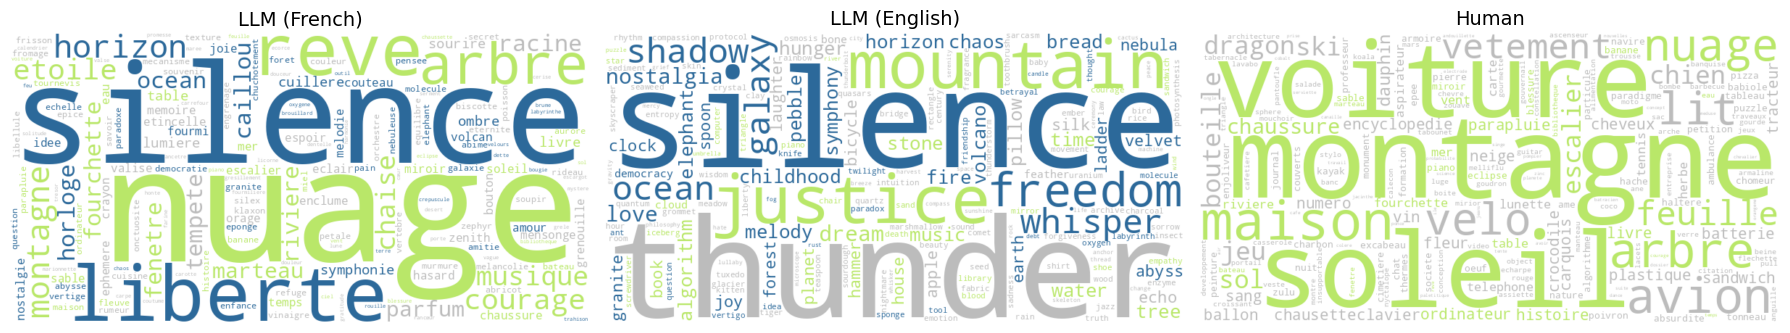

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Corrected figsize

# Word clouds
wordcloud_fr = WordCloud(width=800, height=400, background_color='white', color_func=custom_color_french).generate(all_words_fr)
wordcloud_en = WordCloud(width=800, height=400, background_color='white', color_func=custom_color).generate(all_words_en)
wordcloud_human = WordCloud(width=800, height=400, background_color='white', color_func=custom_color_french).generate(all_words_human)

# Titles
titles = ["LLM (French)", "LLM (English)", "Human"]

for ax, wc, title in zip(axes, [wordcloud_fr, wordcloud_en, wordcloud_human], titles):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("../data/wordclouds.png", dpi=600, bbox_inches='tight')  # High-res PNG
plt.show()